# Word Embeddings with Keras

# Outline
- Word embedding
- BoW and TF-IDF
- Word2Vec
- Building a spam detection model with Keras and Word2Vec

In [ ]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists


# What is word embedding?
It's a technique to map words or phrases from a vocabulary to vectors of real numbers.

# Bag of words: BoW

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample text data
documents = [
    "Hello, how are you?",
    "Are you learning NLP?",
    "NLP is fun!",
]
# Create an instance of CountVectorizer with stop words removed
vectorizer = CountVectorizer()
# Fit the model and transform the documents into a BoW model
bow_matrix = vectorizer.fit_transform(documents)
# Convert the BoW model into an array and print it
print(bow_matrix.toarray())
# Print the feature names (vocabulary)
print(vectorizer.get_feature_names_out())

[[1 0 1 1 0 0 0 1]
 [1 0 0 0 0 1 1 1]
 [0 1 0 0 1 0 1 0]]
['are' 'fun' 'hello' 'how' 'is' 'learning' 'nlp' 'you']


In this case, each text is transformed into a lookup table in which the number of times a word appears is counted. At this level, each text is mapped into a vector, we are not working at word level.

## Stop words

Stop words are common words that carry minimal individual meaning and are abundant in the language, such as "the", "is", "in", and "and". Although these words are essential for sentence construction, they often add little value to text analysis and machine learning models.

Instead of keeping words that don't add information, **we remove them to reduce the size of the vocabulary and make the model more efficient**.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample text data
documents = [
    "Hello, how are you?",
    "Are you learning NLP?",
    "NLP is fun!",
]

# Create an instance of CountVectorizer with stop words removed
vectorizer = CountVectorizer(stop_words='english')

# Fit the model and transform the documents into a BoW model
bow_matrix = vectorizer.fit_transform(documents)

# Convert the BoW model into an array and print it
print(bow_matrix.toarray())

# Print the feature names (vocabulary)
print(vectorizer.get_feature_names_out())


[[0 1 0 0]
 [0 0 1 1]
 [1 0 0 1]]
['fun' 'hello' 'learning' 'nlp']


Let's build a model starting with this.

# Spam detection

The SMS Spam Collection is a dataset of 5,574 SMS messages sorted into:
* ham (regular messages)
* spam (junk messages)

In [ ]:
import tensorflow as tf
import os

# Function to download and read the dataset
def download_and_read(url):
    # Extracts the filename from the URL
    local_file = url.split('/')[-1]

    # Downloads the dataset using TensorFlow utility and extracts it
    # Note: get_file returns the path to the extracted directory
    dataset_path = tf.keras.utils.get_file(local_file, url,
                                          extract=True, cache_dir=".")

    # Construct the path to the SMSSpamCollection file
    # by assuming it's in the extracted directory
    local_file = os.path.join(dataset_path, "SMSSpamCollection")

    # Initialize empty lists for labels and texts
    labels, texts = [], []

    # Open the dataset file and read line by line
    with open(local_file, "r") as fin:
        for line in fin:
            # Each line has a label and a text message separated by a tab
            label, text = line.strip().split('\t')

            # Convert "spam" to 1 and "ham" (non-spam) to 0
            labels.append(1 if label == "spam" else 0)

            # Store the message text
            texts.append(text)

    # Return the extracted texts and labels
    return texts, labels

# URL of the SMS Spam Collection dataset
DATASET_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

# Call the function to download and read the dataset
texts, labels = download_and_read(DATASET_URL)

In [ ]:
# Print content of downloaded data

print(texts[:3])
print(labels[:3])
#0 → ham
#1 → spam

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...', 'Ok lar... Joking wif u oni...', "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]
[0, 0, 1]


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd

# Create a DataFrame using the extracted text messages
spam_df = pd.DataFrame(texts, columns=['content'], index=range(0, len(labels)))

# Add the 'label' column with spam (1) and ham (0) values
spam_df['label'] = labels

# Display the DataFrame (only works in Jupyter Notebooks)
display(spam_df)


,content,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,1
5570,Will ü b going to esplanade fr home?,0
5571,"Pity, * was in mood for that. So...any other s...",0
5572,The guy did some bitching but I acted like i'd...,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Preprocess the text
vectorizer = CountVectorizer(stop_words='english') # performance don't change with stop_words.
X_bow = vectorizer.fit_transform(spam_df['content'])


In [ ]:
print(f"Single words: {len(vectorizer.get_feature_names_out())}")

Single words: 8444


In [ ]:

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bow, spam_df['label'], test_size=0.2, random_state=42)

# Step 3: Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth = 5)
clf.fit(X_train, y_train)

# Step 4: Evaluate the model
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8556053811659193
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       954
           1       0.00      0.00      0.00       161

    accuracy                           0.86      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.73      0.86      0.79      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Refresher
<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/800px-Precisionrecall.svg.png' width=400>

## ANN approach

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8800 - loss: 0.4929 - val_accuracy: 0.9215 - val_loss: 0.2607
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9784 - loss: 0.1194 - val_accuracy: 0.9742 - val_loss: 0.0860
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9958 - loss: 0.0271 - val_accuracy: 0.9776 - val_loss: 0.0706
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9994 - loss: 0.0095 - val_accuracy: 0.9776 - val_loss: 0.0751
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9997 - loss: 0.0051 - val_accuracy: 0.9776 - val_loss: 0.0805


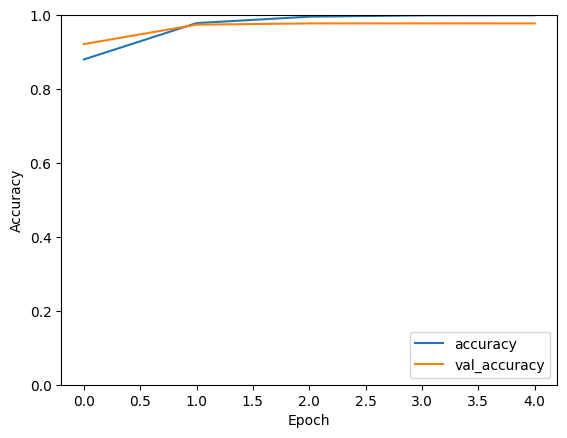

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


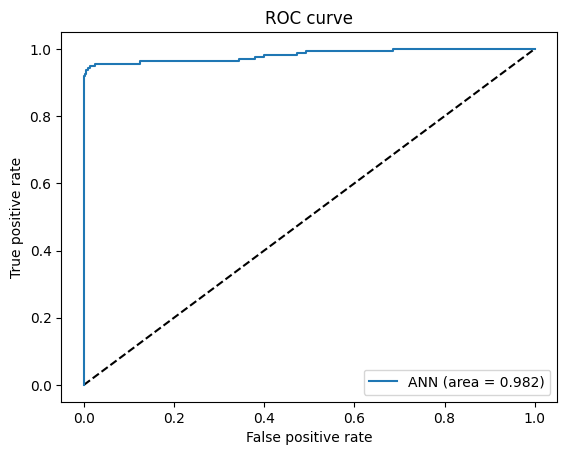

AUC: 0.9816138651249399


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import History

# Preprocess the text
vectorizer = CountVectorizer(stop_words='english')
X_bow = vectorizer.fit_transform(spam_df['content'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_bow.toarray(), spam_df['label'], test_size=0.2, random_state=42)

# Define the ANN Model
model_bow = Sequential([
    #128 neurons, takes a vector of 8,444 features (words) as input.
    Dense(128, activation='relu', input_shape=(8444,)), # We measured the number of single words before (we are deleating stop words)
    #64 neurons for feature extraction.
    Dense(64, activation='relu'),
    #1 neuron (outputs probability between 0 and 1 for spam classification).
    Dense(1, activation='sigmoid')
])

model_bow.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model
history = model_bow.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

# Plot Training History
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# Evaluate ROC and AUC
y_pred_proba = model_bow.predict(X_test).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='ANN (area = {:.3f})'.format(auc))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

print('AUC:', auc)


# TF-IDF

The TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus. **This helps to adjust for the fact that some words appear more frequently in general.**



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Preprocess
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(spam_df['content'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, spam_df['label'], test_size=0.2, random_state=42)


In [ ]:
# Step 2: Train a Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Evaluate the Model
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9811659192825112
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       954
           1       1.00      0.87      0.93       161

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# Word2Vec x Gensim: playground

Gensim is an open-source Python library particularly useful for analyzing large-scale text data, allowing for the easy implementation of popular algorithms like Word2Vec for semantic analysis.

We'll use the `text8` dataset, a compact and cleaned-up version of the English Wikipedia text and the `Word2Vec` model for efficiently learning vector representations of words from large datasets.

In [ ]:
#!pip uninstall -y numpy scipy gensim
#!pip install numpy==1.23.5 scipy==1.10.1 gensim==4.3.2


In [ ]:
#!pip install gensim # Install the gensim library

import gensim.downloader as api
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# Load the text8 dataset
dataset = api.load("text8")

# Convert dataset to a list of words
# Note: The dataset is a generator, so we need to iterate over it to access its content
text8_data = [word for text in dataset for word in text]

# Display the first 100 words to give an idea of the content
print("First 100 words of the text8 dataset:")
print(text8_data[:100])

First 100 words of the text8 dataset:
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english', 'revolution', 'and', 'the', 'sans', 'culottes', 'of', 'the', 'french', 'revolution', 'whilst', 'the', 'term', 'is', 'still', 'used', 'in', 'a', 'pejorative', 'way', 'to', 'describe', 'any', 'act', 'that', 'used', 'violent', 'means', 'to', 'destroy', 'the', 'organization', 'of', 'society', 'it', 'has', 'also', 'been', 'taken', 'up', 'as', 'a', 'positive', 'label', 'by', 'self', 'defined', 'anarchists', 'the', 'word', 'anarchism', 'is', 'derived', 'from', 'the', 'greek', 'without', 'archons', 'ruler', 'chief', 'king', 'anarchism', 'as', 'a', 'political', 'philosophy', 'is', 'the', 'belief', 'that', 'rulers', 'are', 'unnecessary', 'and', 'should', 'be', 'abolished', 'although', 'there', 'are', 'differing']


In [ ]:
# It should take some minutes ca.
model = Word2Vec(dataset)  # Training a Word2Vec model on the dataset
model.save("data/text8-word2vec.bin")  # Saving the trained model

The actual word vectors can be accessed as a custom Gensim class from the model’s `wv` attribute.

In [ ]:
w2v_model = KeyedVectors.load("data/text8-word2vec.bin")
word_vectors = model.wv

# get words in the vocabulary
words = word_vectors.key_to_index # Retriving a dictionary from the Word2Vec model where keys are words in the vocabulary and values are their corresponding indices in the model's internal matrices
print([x for i, x in enumerate(words) if i < 10])
print("king" in words)

['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'two']
True


How to compute the similarity between the vector representation of a world (like `"king"`) and the vectors of all other words in the vocabulary.

In [ ]:
word_vectors.most_similar("king")

[('prince', 0.7258327603340149),
 ('emperor', 0.7156481146812439),
 ('queen', 0.7013669013977051),
 ('throne', 0.687824547290802),
 ('pharaoh', 0.681235671043396),
 ('vii', 0.6733690500259399),
 ('kings', 0.6720716953277588),
 ('aragon', 0.6638478636741638),
 ('regent', 0.6615498065948486),
 ('sultan', 0.6589395403862)]

We can print the result in a more systematic way

In [ ]:
def print_most_similar(word_conf_pairs, k):
    for i, (word, conf) in enumerate(word_conf_pairs):
        print("{:.3f} {:s}".format(conf, word))
        if i >= k-1:
            break
    if k < len(word_conf_pairs):
        print("...")

print("# words similar to king")
print_most_similar(word_vectors.most_similar("king"), 5)

# words similar to king
0.726 prince
0.716 emperor
0.701 queen
0.688 throne
0.681 pharaoh
...


Our objective is to see if the relation(Paris, France) is the same relation(Berlin, Germany).

This is equivalent to saying that the distance in embedding space between Paris and France should be the same as that between Berlin and Germany.

In other words, France - Paris + Berlin should give us Germany.

In code, then, this would translate to

In [ ]:
print_most_similar(word_vectors.most_similar(
 positive=["france", "berlin"], negative=["paris"]), 1
)

0.802 germany
...


In [ ]:
print_most_similar(word_vectors.most_similar(
 positive=["france", "rome"], negative=["paris"]), 1
)

0.689 constantinople
...


In [ ]:
print_most_similar(word_vectors.most_similar(
 positive=["athens", "rome"], negative=["greece"]), 1
)

0.716 temple
...


We can also play "find the intruder" in a list of names

In [ ]:
list_of_names = ["football", "soccer", "taekwondo", "basketball"]
print(word_vectors.doesnt_match(list_of_names))

taekwondo


In [ ]:
list_of_names = ["apple", "pear", "peach", "pepper"]
print(word_vectors.doesnt_match(list_of_names))

apple


# Building a spam detection model with Keras and Word2Vec

In [ ]:
# Create a pandas dataframe
import numpy as np
import pandas as pd

spam_df = pd.DataFrame(texts, columns=['content'], index=range(0, len(labels)))
spam_df['label'] = labels
display(spam_df)

,content,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,1
5570,Will ü b going to esplanade fr home?,0
5571,"Pity, * was in mood for that. So...any other s...",0
5572,The guy did some bitching but I acted like i'd...,0


In [ ]:
from gensim.utils import simple_preprocess
# Transform the content column into a list
spam_df['content_list'] = spam_df['content'].apply(lambda x: simple_preprocess(x))
spam_df.head()


,content,label,content_list
0,"Go until jurong point, crazy.. Available only ...",0,"[go, until, jurong, point, crazy, available, o..."
1,Ok lar... Joking wif u oni...,0,"[ok, lar, joking, wif, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,"[free, entry, in, wkly, comp, to, win, fa, cup..."
3,U dun say so early hor... U c already then say...,0,"[dun, say, so, early, hor, already, then, say]"
4,"Nah I don't think he goes to usf, he lives aro...",0,"[nah, don, think, he, goes, to, usf, he, lives..."


We have a problem! Our input has different shapes!

In [ ]:
import gensim.downloader as api
import numpy as np
import os
import shutil
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix

## Mean
We'll create a simple ANN in which the tokens in content_list will be transformed in vectors. Therefore a contet will be transformed in a vector of size 100 x N_tokens.

To overcome this inhomogenity we'll average each vector thus obtaining an array of dimension 100 for each content.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(spam_df['content_list'],
                                                    spam_df['label'], test_size=0.2)
X_train = X_train.reset_index(drop = True)
X_test = X_test.reset_index(drop = True)


In [ ]:
# Extract the set of words present in the Word2Vec model's vocabulary
words = set(w2v_model.wv.index_to_key)

# Convert X_train texts into vectors using the Word2Vec model
# Only include words that are present in the model's vocabulary
X_train_vect = [
    np.array([w2v_model.wv[i] for i in ls if i in words]) for ls in X_train
]

# Convert X_test texts into vectors using the Word2Vec model
# Only include words that are present in the model's vocabulary
X_test_vect = [
    np.array([w2v_model.wv[i] for i in ls if i in words]) for ls in X_test
]

# Initialize lists to store the average vectors for each document in the training set
X_train_avg = []

# Calculate the average vector for each document in the training set
for v in X_train_vect:
    if len(v) > 0:  # Check if v is not empty to avoid division by zero
        X_train_avg.append(v.mean(axis=0))
    else:
        X_train_avg.append(np.zeros(shape=(w2v_model.vector_size,)))  # Append a zero vector if v is empty

# Initialize lists to store the average vectors for each document in the test set
X_test_avg = []

# Calculate the average vector for each document in the test set
for v in X_test_vect:
    if len(v) > 0:  # Check if v is not empty to avoid division by zero
        X_test_avg.append(v.mean(axis=0))
    else:
        X_test_avg.append(np.zeros(shape=(w2v_model.vector_size,)))  # Append a zero vector if v is empty

X_train_avg = np.array(X_train_avg)
X_test_avg = np.array(X_test_avg)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Assuming X_train_avg and X_test_avg are your averaged word vector representations
input_dim = X_train_avg.shape[1]  # The number of features (word vector dimensions)

model_mean = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Add f1_score to the metrics in model.compile()
model_mean.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model_mean.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,249 (83.00 KB)

 Trainable params: 21,249 (83.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Learn
history = model_mean.fit(X_train_avg, y_train,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_test_avg, y_test))

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9242 - loss: 0.1986 - val_accuracy: 0.9516 - val_loss: 0.1377
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9637 - loss: 0.1110 - val_accuracy: 0.9641 - val_loss: 0.1066
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9733 - loss: 0.0871 - val_accuracy: 0.9668 - val_loss: 0.0949
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9782 - loss: 0.0716 - val_accuracy: 0.9713 - val_loss: 0.0902
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.9722 - val_loss: 0.1065
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9841 - loss: 0.0491 - val_accuracy: 0.9749 - val_loss: 0.0870
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9861 - loss: 0.0423 - val_accuracy: 0.9785 - val_loss: 0.0913
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0328 - val_accu